In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv(r"/content/EDITED_DATASET.csv")

In [ ]:
df

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,City,Gender,Country,Clicked on Ad,Unnamed: 8
0,62.26,32,69481.85,172.83,Lisafort,Male,Svalbard & Jan Mayen Islands,0,NaN
1,41.73,31,61840.26,207.17,West Angelabury,Male,Singapore,0,NaN
2,44.40,30,57877.15,172.83,Reyesfurt,Female,Guadeloupe,0,NaN
3,59.88,28,56180.93,207.17,New Michael,Female,Zambia,0,NaN
4,49.21,30,54324.73,201.58,West Richard,Female,Qatar,1,NaN
...,...,...,...,...,...,...,...,...,...
9995,41.73,31,61840.26,207.17,West Angelabury,Male,Singapore,1,NaN
9996,41.73,28,51501.38,120.49,Kennedyfurt,Male,Luxembourg,0,NaN
9997,55.60,39,38067.08,124.44,North Randy,Female,Egypt,0,NaN
9998,46.61,50,43974.49,123.13,North Samantha,Female,Malawi,1,NaN


# DATA OVERVIEW

In [ ]:
df=df.drop('Unnamed: 8', axis=1)

In [ ]:
df.shape

(10000, 8)

In [ ]:
#Checking for non null values and datatype in each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  10000 non-null  float64
 1   Age                       10000 non-null  int64  
 2   Area Income               10000 non-null  float64
 3   Daily Internet Usage      10000 non-null  float64
 4   City                      10000 non-null  object 
 5   Gender                    10000 non-null  object 
 6   Country                   10000 non-null  object 
 7   Clicked on Ad             10000 non-null  int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 625.1+ KB


In [ ]:
#Stats about every numerical column
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Clicked on Ad
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,61.660757,35.940100,53840.047721,177.759831,0.491700
std,15.704142,8.572973,13343.708718,40.820951,0.499956
min,32.600000,19.000000,13996.500000,105.220000,0.000000
25%,48.860000,29.000000,44052.302500,140.150000,0.000000
50%,59.590000,35.000000,56180.930000,178.920000,0.000000
75%,76.580000,42.000000,61840.260000,212.670000,1.000000
max,90.970000,60.000000,79332.330000,269.960000,1.000000


In [ ]:
#stats of categorical columns

df.describe(include='object')

,City,Gender,Country
count,10000,10000,10000
unique,521,2,207
top,Hubbardmouth,Female,Australia
freq,336,5376,388


In [ ]:
#checking whether the dataset is balanced or not

df['Clicked on Ad'].value_counts()

,count
Clicked on Ad,
0,5083
1,4917


In [ ]:
#check for duplicate rows

print("number of duplicate rows:", df.duplicated().sum())


number of duplicate rows: 556


In [ ]:
dup_rows=df[df.duplicated()]
dup_rows['Clicked on Ad'].value_counts()

,count
Clicked on Ad,
1,299
0,257


since there not much disparity in the classes the duplicate belong to, thus removal of these duplicates wont make the dataset imbalanced.

In [ ]:
df=df.drop_duplicates()

# UNIVARIATE ANALYSIS

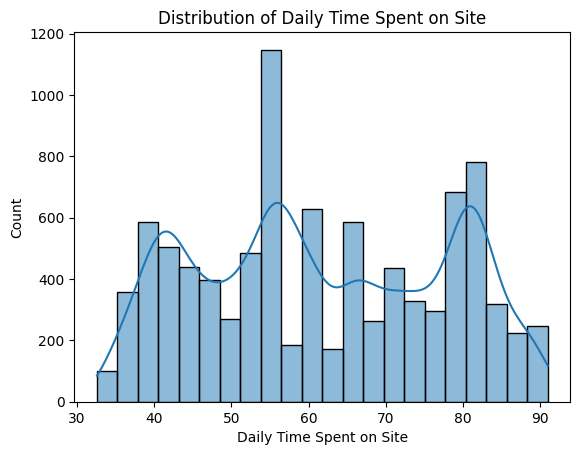

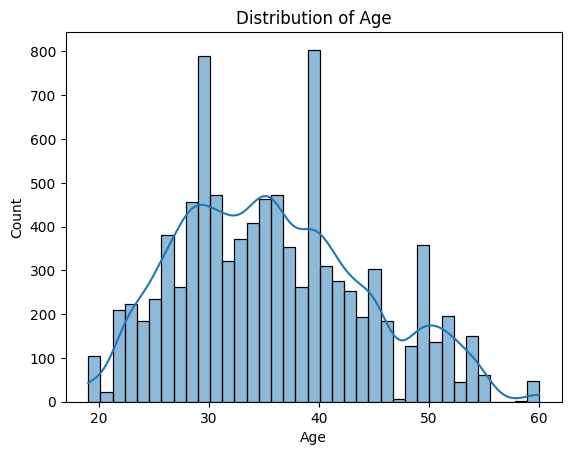

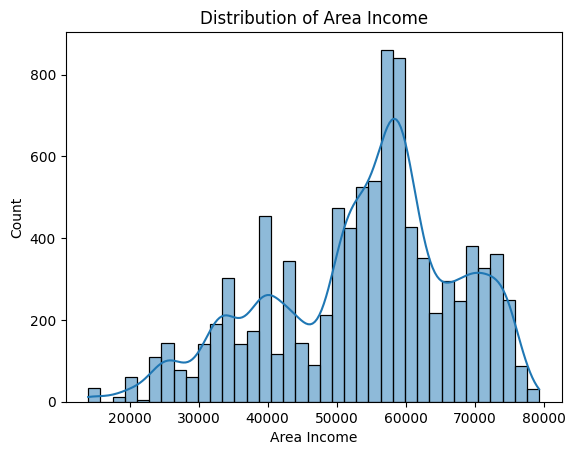

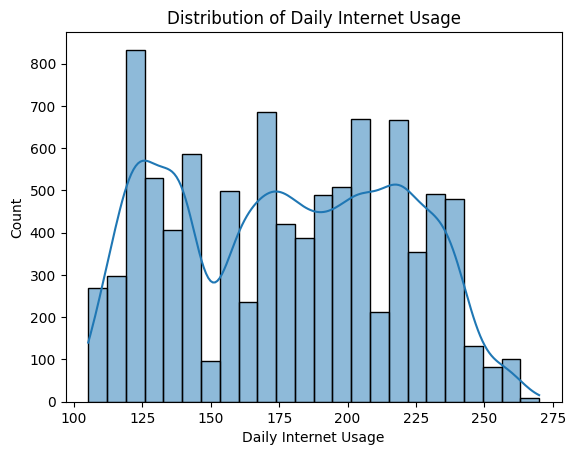

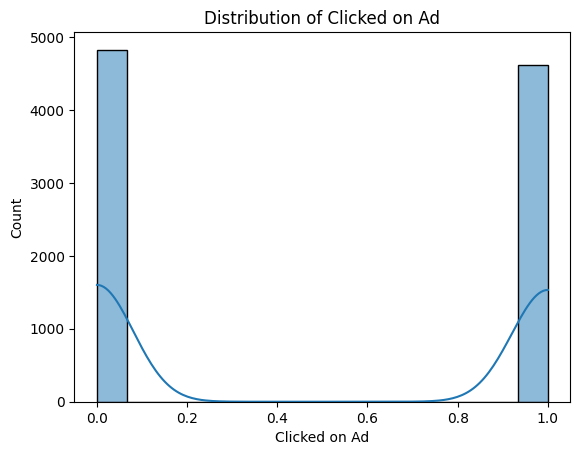

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

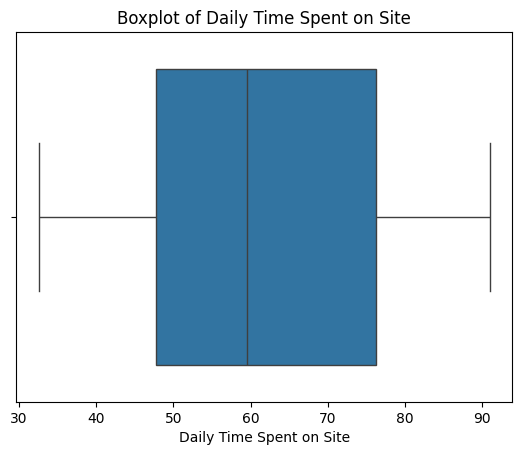

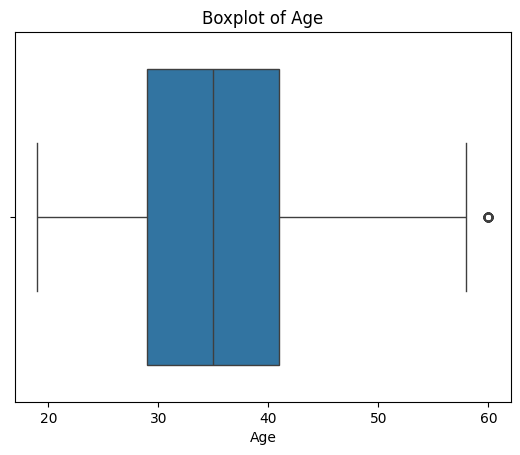

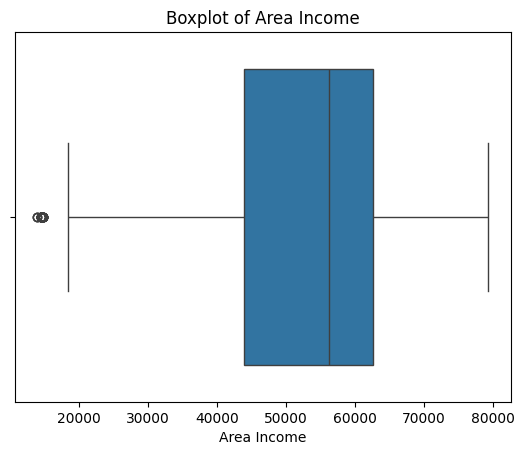

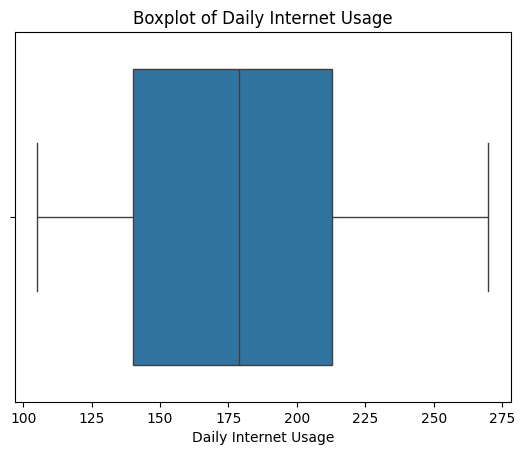

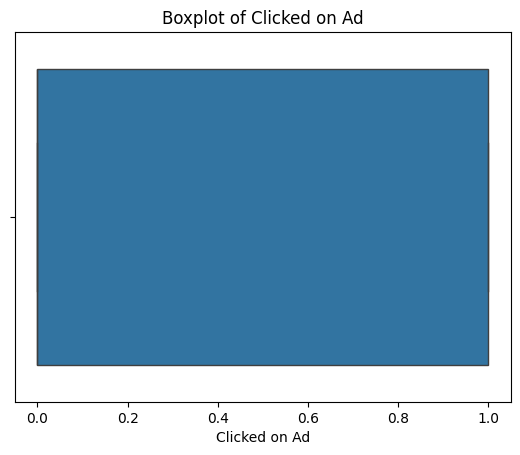

In [ ]:
#check for outliers

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

The above outliers represent occurence of rare events rather than being any random noise and thus cannot be removed

# CORRELATION ANALYSIS

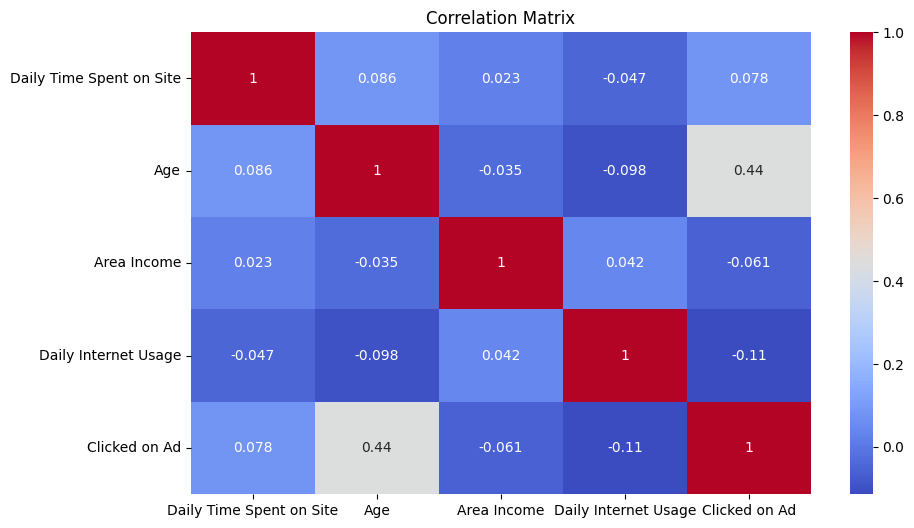

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The dataset shows generally weak correlations, except for Age with Clicked on Ad. Hinting towards the likely non linear realtionship between features and target variable.

# BIVARIATE ANALYSIS



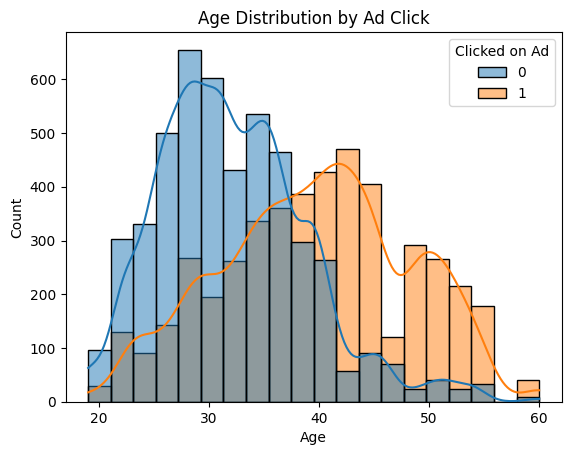

In [ ]:
# age distribution by ad-click

sns.histplot(data=df, x='Age', hue='Clicked on Ad', bins=20, kde=True)

plt.title("Age Distribution by Ad Click")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

The distribution shows a clear demographic pattern. Non-clickers are concentrated around the 25–35 age range, while clickers are more frequent between 35 and 55. This suggests age is an important segmentation variable. However, there is overlap around ages 30–40, indicating that age alone cannot fully explain click behavior, and additional features will be required for accurate prediction.




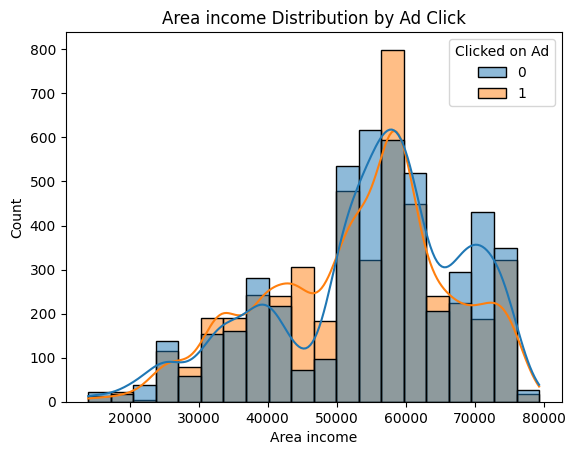

In [ ]:
# area income distribution by ad-click

sns.histplot(data=df, x='Area Income', hue='Clicked on Ad', bins=20, kde=True)

plt.title("Area income Distribution by Ad Click")
plt.xlabel("Area income")
plt.ylabel("Count")
plt.show()

The distribution shows that most users fall within the 50k–65k income range. While ad clicks peak around 60k income, there is significant overlap between clickers and non-clickers across most income levels. This indicates that area income alone is not a strong predictor of ad engagement, which is also consistent with the low correlation observed earlier.

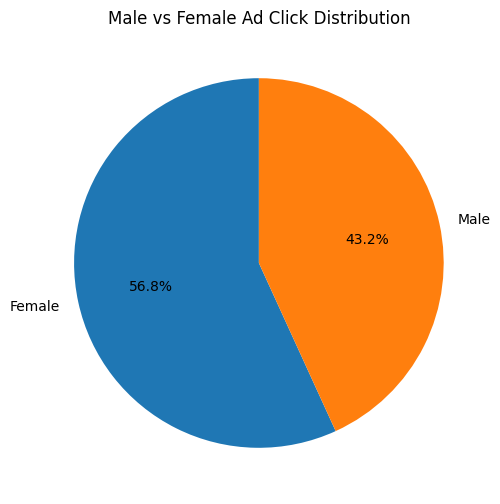

In [ ]:
clicked = df[df['Clicked on Ad'] == 1]

gender_counts = clicked['Gender'].value_counts()

plt.figure(figsize=(6,6))
gender_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)

plt.title('Male vs Female Ad Click Distribution')
plt.ylabel('')
plt.show()

This chart shows, out of all users who clicked the ad, 56.8% of them were female and rest were male.

In [ ]:
# % gender distribution in the full dataset
dataset_dist = df['Gender'].value_counts(normalize=True) * 100

# % gender distribution among those who clicked
click_dist = df[df['Clicked on Ad'] == 1]['Gender'].value_counts(normalize=True) * 100

# combine into one dataframe
comparison_df = pd.DataFrame({
    '% in Dataset': dataset_dist,
    '% of Clicks': click_dist
})

comparison_df

,% in Dataset,% of Clicks
Gender,,
Female,53.864888,56.821135
Male,46.135112,43.178865


Females represent about 53.9% of the total users but account for approximately 56.8% of the ad clicks(~3% response uplift), indicating they are slightly more responsive to the advertisement. However, the difference is relatively small, suggesting gender alone may not be a strong predictor of click behavior.

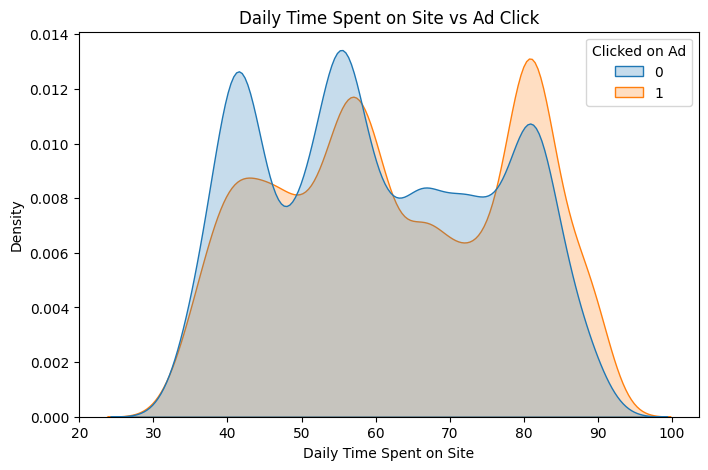

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='Daily Time Spent on Site', hue='Clicked on Ad', fill=True)

plt.title('Daily Time Spent on Site vs Ad Click')
plt.show()

From the KDE plot, we can observe that users who spend less time on the site tend to click on ads more frequently, while those who spend more time on the site are less likely to click on ads. This suggests an inverse relationship between the daily time spent on the site and the likelihood of clicking an ad.

In [ ]:
df['Country'].value_counts()

,count
Country,
Australia,319
Czech Republic,315
Turkey,283
Hong Kong,221
Qatar,214
...,...
Paraguay,1
Mozambique,1
Saint Barthelemy,1


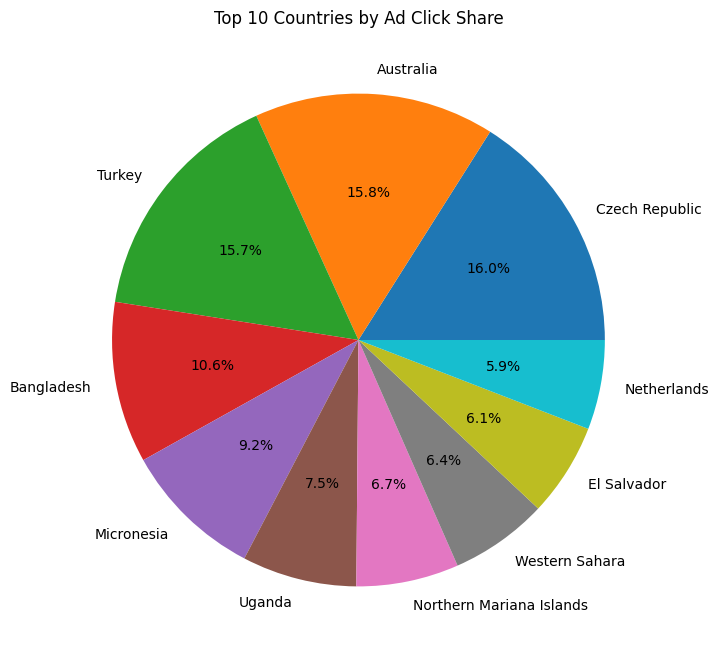

In [ ]:
#TOP 10 countries generating most clicks

country_clicks = df[df['Clicked on Ad']==1]['Country'].value_counts().head(10)

country_clicks.plot(kind='pie', autopct='%1.1f%%', figsize=(8,8))
plt.title("Top 10 Countries by Ad Click Share")
plt.ylabel('')
plt.show()

In [ ]:
df.groupby('Country')['Clicked on Ad'].agg(['count','sum','mean'])

,count,sum,mean
Country,,,
Afghanistan,38,30,0.789474
Albania,95,64,0.673684
Algeria,110,34,0.309091
American Samoa,89,16,0.179775
Andorra,13,2,0.153846
...,...,...,...
Wallis and Futuna,1,0,0.000000
Western Sahara,110,105,0.954545
Yemen,6,0,0.000000


In [ ]:
region_map = {
    'United States': 'North America',
    'Canada': 'North America',
    'Mexico': 'North America',

    'United Kingdom': 'Europe',
    'Germany': 'Europe',
    'France': 'Europe',
    'Spain': 'Europe',
    'Italy': 'Europe',

    'India': 'Asia',
    'China': 'Asia',
    'Japan': 'Asia',
    'South Korea': 'Asia',

}

df['Region'] = df['Country'].map(region_map).fillna('Others')

ctr_region = df.groupby('Region')['Clicked on Ad'].mean().reset_index()

ctr_region['CTR %'] = ctr_region['Clicked on Ad'] * 100
ctr_region = ctr_region.sort_values(by='CTR %', ascending=False)

print(ctr_region)

          Region  Clicked on Ad      CTR %
0           Asia       0.800000  80.000000
3         Others       0.489424  48.942370
2  North America       0.387097  38.709677
1         Europe       0.231707  23.170732


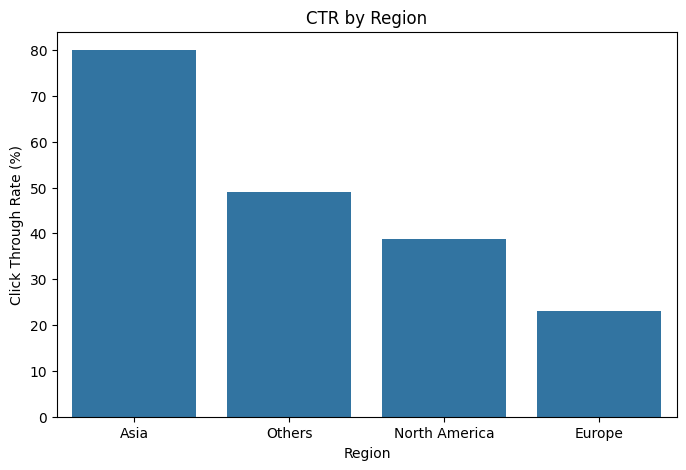

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(data=ctr_region, x='Region', y='CTR %')

plt.title('CTR by Region')
plt.ylabel('Click Through Rate (%)')
plt.xlabel('Region')

plt.show()

This analysis suggests that geographical region could be crucial for optimizing ad campaigns by focusing efforts on high-performing regions like Asia, and potentially re-evaluating strategies for lower-performing regions like Europe.



# SUMMARY

## Dataset Profile & Integrity:

The analysis was conducted on a dataset of 10,000 observations encompassing user demographics and their digital behavior. With a nearly identical distribution between positive and negative outcomes (49.17% CTR), the dataset provides a robust, non-biased foundation for training binary classification models.

## Strategic Insights :

1. Demographic Sweet Spot: The peak engagement age is centered at 36 years, with an average area income of $53,840. This suggests that the current advertising creative or product offering resonates most strongly with established, mid-career professionals.

2. Feature Correlation: The strong unimodal distribution of Area Income peaking at $60,000 implies that purchasing power is a stable covariate, whereas digital usage patterns are more volatile and segment-specific.

3. Geographic Location: geographical region could be crucial for optimizing ad campaigns by focusing efforts on high-performing regions like Asia, and potentially re-evaluating strategies for lower-performing regions like Europe.

##Key Behavioral Indicators:

The Exploratory Data Analysis (EDA) identifies Daily Time Spent on Site as the primary driver of user engagement. Both metrics follow a distinct bimodal distribution, revealing two clear user archetypes:

1. High-Engagement Core: Users spending ~80+ minutes on-site, likely representing high-intent brand advocates.

2. Low-Engagement Casuals: Users spending less than 45 minutes, representing a segment requiring different re-engagement or retargeting strategies.